# 引入所需的函式庫:
### 1. MDAnalysis: 讀取和處理原始的模擬軌跡數據，並提取出需要的物理量。
### 2. MDAnalysis.analysis.distances: 一種拿來計算原子和原子組之間距離的函式庫。
### 3. Numpy: 用於高效地存儲和計算這些提取出來的數值數據（例如，將原子座標轉換為距離陣列），主要的目的是讓清單(list)可以和整數或浮點數進行四則運算。
### 4. SYS: 一種 python 的標準內建模組，提供了許多與 Python 解釋器相關的函式和變數。

In [22]:
from MDAnalysis import *
import MDAnalysis.analysis.distances as distances
import numpy as np
import sys

# 管理所需的檔案:
### 先利用 topology = "start_drudes.pdb" 和 trajectory = "FV_NVT.dcd" 找到所需檔案的路徑，記得把程式碼與所需的pdb和dcd檔放在同一個路徑裡，才能直接讀取路徑(如果不在同一個路徑裡，則需要用絕對路徑的方式才能讀到檔案)。
### 再建立一個Universe去管理需要的pdb和dcd檔。
### u.guess_TopologyAttrs(context='default', to_guess=['elements']): 讓MDAnalysis嘗試自動推斷或「猜測」Universe 物件中缺失或未知的拓撲屬性(記得補這一行)。

In [24]:
#set the pdb topology and dcd trajectory
topology = "start_drudes.pdb"
trajectory = "FV_NVT.dcd"

# load trajectory into Universe
u = Universe(topology, trajectory)
u.guess_TopologyAttrs(context='default', to_guess=['elements'])

/home/atuo/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:346: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/home/atuo/anaconda3/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [25]:
# contact distance with electrodes
r_electrode_contact = np.array([ 6.0 , 6.0 , 6.0 , 6.0 ] )

# maximum z distance for pulling BF4 ions, this should be farther than the electrode extends in z...
z_max = 55
rdf_max = 15 # maximum distance to compute rdf
n_bins = 75 # rdf bins
dr = float(rdf_max) / float(n_bins)

# frame to start, may want to skip frames for equilibration
# framestart=5000
framestart=1000
frameend=len(u.trajectory)-1

# set the atoms for computing RDF
resname1='trf'
atoms1='Cf'
resname2='BMI'
atoms2=('C1','C2','C21')

#define the environment classifiers.  These should be strings for atom selections...
classifier=[]
classifier.append( "segid A" )
classifier.append( "segid B" )
classifier.append( "segid C" )
classifier.append( "segid D" )
classifier.append( "segid E" )

#列印結果並確認
print("r_electrode_contact:",r_electrode_contact)
print("dr:",dr)
print("framestart:",framestart)
print("frameend:",frameend)
print("classifier:",classifier)

r_electrode_contact: [6. 6. 6. 6.]
dr: 0.2
framestart: 1000
frameend: 2568
classifier: ['segid A', 'segid B', 'segid C', 'segid D', 'segid E']


In [26]:
# make static atom groups for electrode.  These don't change from frame-to-frame because electrode is fixed
u.trajectory[0]
electrode_groups=[]
for electrode in classifier:
    electrode_groups.append( u.select_atoms(electrode) )

# frame to start, may want to skip frames for equilibration
# framestart=5000
framestart=1000
frameend=len(u.trajectory)-1


# rdf datastructures, 5 environments
environments_counts=2

rdf_count = [ [ 0 for i in range(n_bins) ] for j in range(environments_counts) ]
rdf_N_N = [ 0 for j in range(2) ] # keeps track of number of particles histogramed for normalization
rdf_count=np.asfarray(rdf_count)
rdf_N_N=np.asfarray(rdf_N_N)

# trfl/trfl
rdf_count2 = [ [ 0 for i in range(n_bins) ] for j in range(environments_counts) ]
rdf_N_N2 = [ 0 for j in range(2) ] # keeps track of number of particles histogramed for normalization
rdf_count2=np.asfarray(rdf_count2)
rdf_N_N2=np.asfarray(rdf_N_N2)

# print the results for confirmation
print("u.trajectory[0]:\n",u.trajectory[0])
print("frameend:",frameend)
print("rdf_count:\n",rdf_count)
print("rdf_N_N:\n",rdf_N_N)
print("rdf_count2:\n",rdf_count2)
print("rdf_N_N2:\n",rdf_N_N2)
print("electrode_groups:\n",electrode_groups)

u.trajectory[0]:
 < Timestep 0 with unit cell dimensions [ 49.28   49.28  260.422  90.     90.    120.   ] >
frameend: 2568
rdf_count:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]]
rdf_N_N:
 [0. 0.]
rdf_count2:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [27]:
# loop over trajectory
for t0 in range(framestart, frameend):
    #print( "trajectory frame:" , t0 )
    u.trajectory[t0]

# create frame-specific atom groups, note these will change from frame-to-frame
    group1 =  u.select_atoms("name %s and resname %s and prop z < %s" % (atoms1, resname1, z_max) )
    group2 = u.select_atoms("name XXX")
    for ele in atoms2:
        group2 = group2 +  u.select_atoms("name %s and resname %s and prop z < %s" % (ele, resname2, z_max + rdf_max ) )

    #print("group1")
    #print( group1.indices )
    #print("group2")
    #print( group2.indices )

# get minimum distance between group1 atoms and each electrode
    contact_dist_electrodes=[]
    close_contact_electrodes=[]
    for electrode in electrode_groups:
        dist = distances.distance_array( group1.positions , electrode.positions, box = u.dimensions, backend='OpenMP' )
            # contact distance between group1 atoms and electrode
        contact_dist = np.amin( dist , axis=1 )
        contact_dist_electrodes.append( contact_dist )
    # create arrays of "0" and "1" indicating whether anion is within contact distance of electrode
    #for i in range(len(electrode_groups)):
        #close_contact_electrodes.append( abs(np.heaviside( contact_dist_electrodes[i] - r_electrode_contact[i] , 1)- 1 ) )
  # electrodes 2 and 3 are analogous CNTs, so combine these using a mask and go from 4 to 3 unique electrodes ...
  # do this manually since we need the custom mask here...
  # 1st electrode, graphene sheet
    close_contact_electrodes.append( abs(np.heaviside( contact_dist_electrodes[0] - r_electrode_contact[0] , 1) - 1 ) )
  # combine 2nd and 3rd electrode into 1, these are 2 identical CNTs
    temp1 = abs(np.heaviside( contact_dist_electrodes[1] - r_electrode_contact[1] , 1) - 1 )
    temp2 = abs(np.heaviside( contact_dist_electrodes[2] - r_electrode_contact[2] , 1) - 1 )
    temp1 += temp2
  # use a mask to get "0" and "1" if close to one of the two electrodes
    close_contact_electrodes.append( np.ma.masked_not_equal(temp1,0).mask.astype(int) )
        #print( "temp1" )  ; print( temp1 ) ; print( "temp2" ) ; print( temp2 ) ; print( "combine" ) ;print( close_contact_electrodes[1] )
  # 4th electrode, outer CNT
        #close_contact_electrodes.append( abs(np.heaviside( contact_dist_electrodes[3] - r_electrode_contact[3] , 1) - 1 ) )

    #for i in range(len(contact_dist_electrodes[0])):
        #print( group1[i].ix , contact_dist_electrodes[0][i] , contact_dist_electrodes[1][i] , contact_dist_electrodes[2][i] , contact_dist_electrodes[3][i] )
  # get "environment label" assign 1 2 4 if contact with electrode 1 (2,3) 4, then
  # environments are 
    environment = np.zeros( len(close_contact_electrodes[0]) )
    for i in range(len(close_contact_electrodes)):
        environment += close_contact_electrodes[i] * 2**i
    #print( "electrode ", i)
    #print( close_contact_electrodes[i] )
#print( environment )
# now partition anions into 5 environments:
    environment_atom = [[] for i in range(2)]
    for i in range(len(group1.indices)):
        if environment[i] == 2:
            environment_atom[0].append( group1[i] )#cnt
        elif environment[i] == 3:
            environment_atom[1].append( group1[i] )#grp/t
        #elif environment[i] == :
            #environment_atom[2].append( group1[i] )
        #elif environment[i] == 6:
            #environment_atom[3].append( group1[i] )
        #elif environment[i] == 4:
            #environment_atom[4].append( group1[i] )
        elif environment[i] == 0:
            pass
        else:
            print( " no matched environment for ", environment[i] )
                #sys.exit()
    #for i in range(len(environment_atom)):
        #print( "environment " , i )
        #print( AtomGroup(environment_atom[i]).indices )
            # now add contribution to RDF for each environment
    for i in range(len(environment_atom)):
      # if there are ions in this environment ...
        if environment_atom[i]:
            pairs, dist = distances.capped_distance(  AtomGroup(environment_atom[i]).positions, group2.positions, rdf_max , box = u.dimensions ) 
            count = np.histogram(dist, bins=n_bins, range=(0.0, rdf_max))[0]
          # add to cumulative rdf ..
            rdf_count[i] += count
            rdf_N_N[i] += len(pairs)

          # now BF4/BF4 , use all BF4 anions in group1 for second group
            pairs, dist = distances.capped_distance(  AtomGroup(environment_atom[i]).positions, group1.positions, rdf_max , box = u.dimensions ) 
            count = np.histogram(dist, bins=n_bins, range=(0.0, rdf_max))[0]
          # add to cumulative rdf ..
            rdf_count2[i] += count
            rdf_N_N2[i] += len(pairs)

# print the results for confirmation
print("trajectory frame:" , t0 )
print("group1:\n",group1)
print("group2:\n",group2)
print("contact_dist_electrodes:\n",contact_dist_electrodes)
print("contact_dist:\n",contact_dist)
print("environment:\n",environment)
print("environment_atom:\n",environment_atom)

trajectory frame: 2567
group1:
 <AtomGroup [<Atom 20085: Cf of type C of resname trf, resid 1 and segid J and altLoc >, <Atom 20197: Cf of type C of resname trf, resid 8 and segid J and altLoc >, <Atom 20245: Cf of type C of resname trf, resid 11 and segid J and altLoc >, ..., <Atom 26405: Cf of type C of resname trf, resid 396 and segid J and altLoc >, <Atom 26437: Cf of type C of resname trf, resid 398 and segid J and altLoc >, <Atom 26469: Cf of type C of resname trf, resid 400 and segid J and altLoc >]>
group2:
 <AtomGroup [<Atom 6087: C1 of type C of resname BMI, resid 1 and segid I and altLoc >, <Atom 6157: C1 of type C of resname BMI, resid 3 and segid I and altLoc >, <Atom 6227: C1 of type C of resname BMI, resid 5 and segid I and altLoc >, ..., <Atom 19986: C21 of type C of resname BMI, resid 398 and segid I and altLoc >, <Atom 20021: C21 of type C of resname BMI, resid 399 and segid I and altLoc >, <Atom 20056: C21 of type C of resname BMI, resid 400 and segid I and altLoc >]

In [28]:
# get "edges" of histrogram for normalization
#count,edges = np.histogram(dist, bins=n_bins, range=(0.0, rdf_max))
edges = np.linspace(0.0, rdf_max, n_bins + 1)

# normalize by volume of bin, see MDAnalysis/MDtraj for this code ...
V = (4 / 3) * np.pi * (np.power(edges[1:], 3) - np.power(edges[:-1], 3))

volume_sphere = (4 / 3) * np.pi * rdf_max**3
# normalize
for i in range(len(rdf_count)):
    rdf_count[i] = rdf_count[i] / rdf_N_N[i] / V * volume_sphere
    rdf_count2[i] = rdf_count2[i] / rdf_N_N2[i] / V * volume_sphere

# print normalized rdfs ...
for i in range(len(rdf_count)):
    print(" ",i)
#for j in range(len(rdf_count[i])):
    #print( j * dr , "-" , rdf_count[i][j] , "-" , rdf_count2[i][j] )

  0
  1


In [29]:
with open("rdf_2cnt_otfbmim_cnt.dat", "w") as ofile_rdf_an0:
    for j in range(len(rdf_count[0])):
        print('{0:5.8f}  {1:5.8f}'.format( j*dr, rdf_count[0][j]), file = ofile_rdf_an0)
with open("rdf_2cnt_otfbmim_grp_t.dat", "w") as ofile_rdf_an1:
    for j in range(len(rdf_count[1])):
        print('{0:5.8f}  {1:5.8f}'.format( j*dr, rdf_count[1][j]), file = ofile_rdf_an1)

with open("rdf_2cnt_otfotf_cnt.dat", "w") as ofile_rdf_cat0:
    for j in range(len(rdf_count[0])):
        print('{0:5.8f}  {1:5.8f}'.format( j*dr, rdf_count2[0][j]), file = ofile_rdf_cat0)
with open("rdf_2cnt_otfotf_grp_t.dat", "w") as ofile_rdf_cat1:
    for j in range(len(rdf_count[1])):
        print('{0:5.8f}  {1:5.8f}'.format( j*dr, rdf_count2[1][j]), file = ofile_rdf_cat1)

        
print("done！")

done！


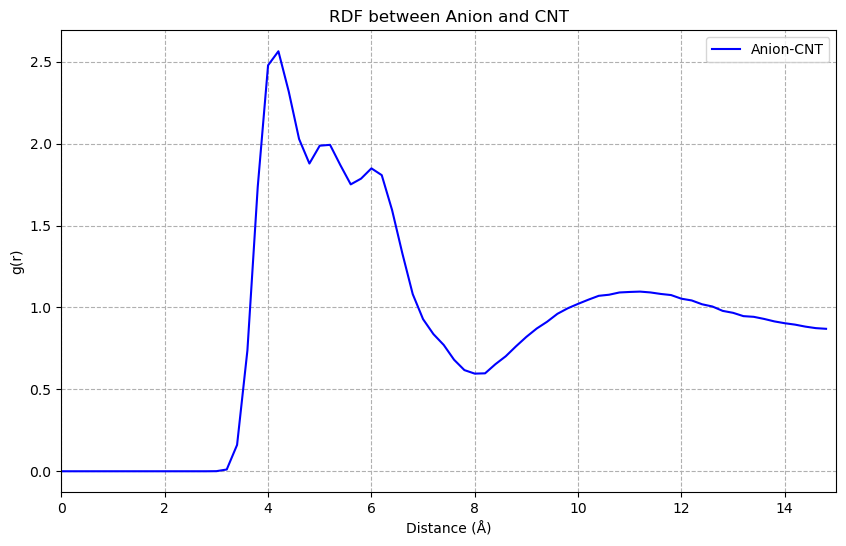

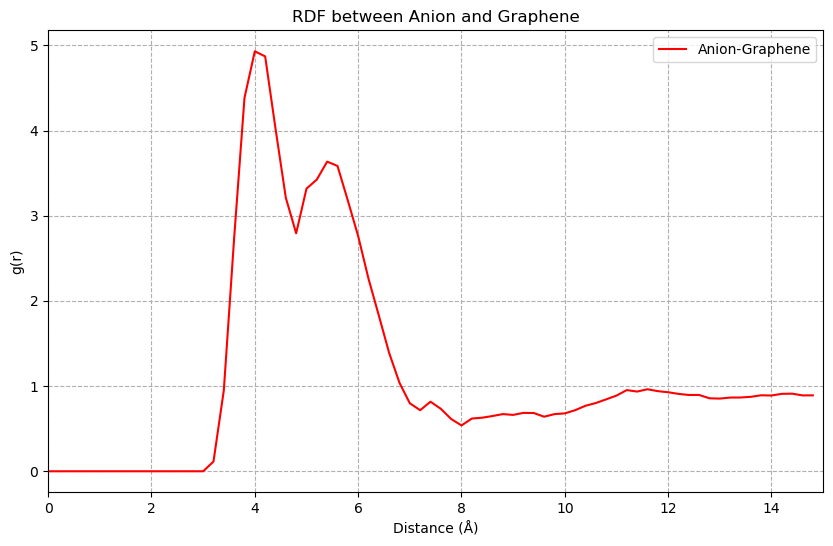

In [30]:
# 引入繪圖函式庫
import matplotlib.pyplot as plt
import numpy as np

# 準備 x 軸的數據 (距離)
r = np.arange(0, rdf_max, dr)

# ---- 繪製第一張圖：離子-石墨烯電極 RDF ----
plt.figure(figsize=(10, 6))
plt.plot(r, rdf_count[0], label='Anion-CNT', color='blue')
plt.title('RDF between Anion and CNT')
plt.xlabel('Distance (Å)')
plt.ylabel('g(r)')
plt.legend()
plt.grid(True, linestyle='--')
plt.xlim(0, rdf_max)
plt.show()

# ---- 繪製第二張圖：離子-奈米碳管 RDF ----
plt.figure(figsize=(10, 6))
plt.plot(r, rdf_count[1], label='Anion-Graphene', color='red')
plt.title('RDF between Anion and Graphene')
plt.xlabel('Distance (Å)')
plt.ylabel('g(r)')
plt.legend()
plt.grid(True, linestyle='--')
plt.xlim(0, rdf_max)
plt.show()